# Spin Chern and mirror Chern numbers
The $Z_2$ invariant of a quantum spin Hall insulator is only a parity, and it needs time-reversal
symmetry. We will now see two invariants that count the helical pairs themselves, with
`h.get_spin_chern()` and `h.get_mirror_chern()`. Both are built the same way: at every k-point the
occupied states are split into two halves by the sign of an operator restricted to them, and each
half has a Chern number of its own. For the spin Chern number the operator is $P s_z P$, the spin
projected on the occupied states, and

$$
C_s = \frac{C_+ - C_-}{2}
$$

counts the helical pairs at each edge. When $s_z$ is conserved the two halves are just the two spin
sectors; when a Rashba coupling mixes them, $C_s$ stays an integer as long as $P s_z P$ keeps a gap
around zero, and with time reversal its parity is the $Z_2$ invariant. The mirror Chern number
splits the occupied states by the eigenvalues $\pm i$ of the mirror $z\to -z$ instead,
$C_M=(C_{+i}-C_{-i})/2$, and it is the invariant of a topological crystalline insulator, where the
mirror, not time reversal, protects the edge states. At the end we will see a third way of
counting, the winding of the hybrid Wannier centers, which gives the Chern number without any
Berry curvature.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology


### The spin Chern number survives a Rashba coupling
We take the Kane-Mele model, the honeycomb lattice with spin-orbit coupling between second
neighbors, and add a growing Rashba coupling, which breaks the conservation of $s_z$. The spin
Chern number stays at $1$, while the integral of the $s_z$-weighted Berry curvature,
`topology.spin_chern`, which is $2C_s$ only while $s_z$ is conserved, drifts away from an integer.
The Rashba coupling also moves the gap away from zero energy, so we put the Fermi energy back
inside it with `h.set_filling(0.5)` before counting the occupied states.

Rashba = 0.0   C_s = 1.0   sz-weighted/2 = 1.007


Rashba = 0.05   C_s = 1.0   sz-weighted/2 = 1.024


Rashba = 0.1   C_s = 1.0   sz-weighted/2 = 1.084


Rashba = 0.15   C_s = 1.0   sz-weighted/2 = 1.237


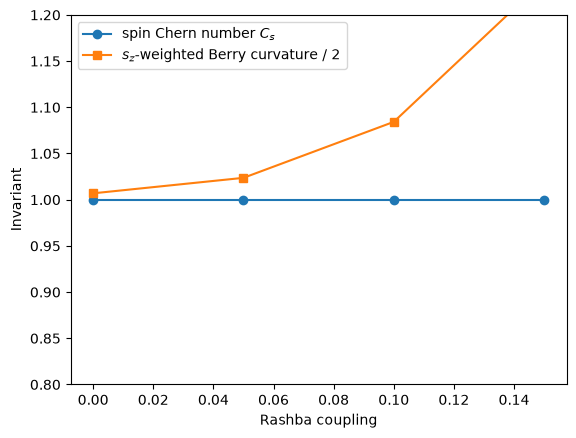

In [2]:
g = geometry.honeycomb_lattice()
rs = [0.,0.05,0.1,0.15] # Rashba coupling
css,ws = [],[]
for r in rs:
    h = g.get_hamiltonian() # spinful honeycomb lattice
    h.add_kane_mele(0.1) # spin-orbit coupling
    h.add_rashba(r) # Rashba coupling, so that sz is not conserved
    h.set_filling(0.5) # put the Fermi energy back inside the gap
    css.append(h.get_spin_chern(nk=12)) # spin Chern number
    ws.append(topology.spin_chern(h,nk=12)/2.) # sz-weighted Berry curvature, halved
    print("Rashba =",r,"  C_s =",round(css[-1],3),"  sz-weighted/2 =",round(ws[-1],3))

plt.plot(rs,css,marker="o",label="spin Chern number $C_s$")
plt.plot(rs,ws,marker="s",label="$s_z$-weighted Berry curvature / 2")
plt.xlabel("Rashba coupling") ; plt.ylabel("Invariant")
plt.legend() ; plt.ylim([0.8,1.2])
plt.show()


### Phase diagram of the mirror Chern number
An out-of-plane exchange field breaks time reversal, so that no $Z_2$ invariant is defined, but it
keeps the mirror $z\to -z$. We map the mirror Chern number over the exchange field and a sublattice
imbalance: it stays at $C_M=-1$ (for a single layer the mirror is $-i\sigma_z$, so $C_M=-C_s$)
until the sublattice imbalance closes the gap and drives the system into a trivial insulator with
$C_M=0$. Where the exchange field pushes the bands of the two spins into each other, the system
becomes a metal, `h.get_gap()` is zero, no invariant is defined, and the map is left blank. The
check has to come first, since a coarse k-mesh can miss the pockets of a metal with a small band
overlap and return a number that is not quantized.

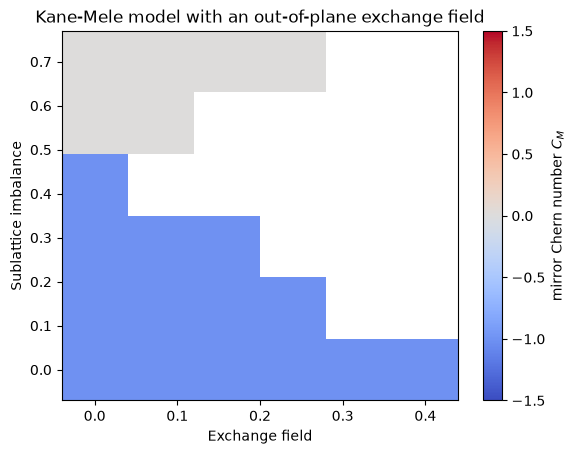

In [3]:
ms = np.linspace(0.,0.4,6) # out-of-plane exchange field
Ms = np.linspace(0.,0.7,6) # sublattice imbalance
CM = np.zeros((len(Ms),len(ms)))
for (i,M) in enumerate(Ms):
    for (j,m) in enumerate(ms):
        h = g.get_hamiltonian() # spinful honeycomb lattice
        h.add_kane_mele(0.1) # spin-orbit coupling
        h.add_exchange([0.,0.,m]) # breaks time reversal, keeps the mirror
        h.add_sublattice_imbalance(M) # sublattice imbalance
        h.set_filling(0.5) # half filling
        if h.get_gap()<1e-3: CM[i,j] = np.nan # a metal, no invariant
        else: CM[i,j] = h.get_mirror_chern(nk=12) # mirror Chern number

dm,dM = ms[1]-ms[0],Ms[1]-Ms[0]
plt.imshow(CM,origin="lower",cmap="coolwarm",vmin=-1.5,vmax=1.5,aspect="auto",
           extent=[ms[0]-dm/2,ms[-1]+dm/2,Ms[0]-dM/2,Ms[-1]+dM/2])
plt.colorbar(label="mirror Chern number $C_M$")
plt.xlabel("Exchange field") ; plt.ylabel("Sublattice imbalance")
plt.title("Kane-Mele model with an out-of-plane exchange field")
plt.show()


### Chern number from the winding of the hybrid Wannier centers
Freezing the momentum $k_2$, the Wilson loop of the occupied bands along the other direction gives
the hybrid Wannier centers, the charge centers of states localized along $\vec a_1$. As $k_2$ goes
once around the Brillouin zone, their sum moves by $C$ lattice constants, meaning that the Chern
number is the charge pumped across the unit cell in one cycle, which is what
`integration="wannier"` counts. For the spinless Haldane model the single center winds once.

Chern number from the Wannier center winding = 1


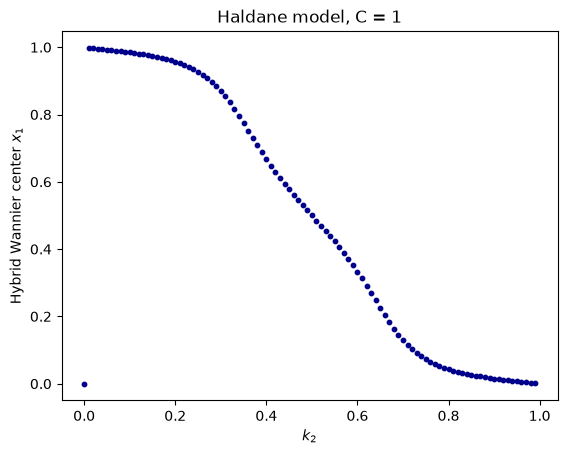

In [4]:
h = g.get_hamiltonian(has_spin=False) # spinless honeycomb lattice
h.add_haldane(0.1) # Haldane coupling, a Chern insulator
C = h.get_chern(integration="wannier",nk=20,nt=40) # winding of the hybrid Wannier centers
print("Chern number from the Wannier center winding =",C)

wc = topology.z2_wannier_centers(h,full=True) # k2 in the first row, centers after it
k2 = wc[0] ; x = np.array(wc[1:])/(2.*np.pi) # centers as fractional coordinates
for xi in x:
    plt.scatter(k2,xi%1.,s=10,c="darkblue")
plt.xlabel("$k_2$") ; plt.ylabel("Hybrid Wannier center $x_1$")
plt.title(f"Haldane model, C = {C}")
plt.show()
